# Lecture 10 — Neural Posterior Estimation (NPE): strengths and weaknesses

This notebook demonstrates **Neural Posterior Estimation** (NPE) on the same astrophysical toy
problem used in Chapter 1 and in the ABC notebook (`lecture_10_ABC.ipynb`): inferring a star's
**distance $d$ and luminosity $L$** from a single noisy **flux** measurement,
$$F = \frac{L}{4\pi d^2}, \qquad F_{\rm obs} = F + \epsilon,\quad \epsilon\sim\mathcal{N}(0,\sigma_F^2).$$

We use the [`sbi`](https://sbi.readthedocs.io) package, whose density estimators are the
**conditional normalizing flows** introduced in Chapter 2. NPE trains a flow
$q_\phi(d,L\mid F)$ on simulated pairs and then returns the posterior for *any* observed flux
**instantly** (amortization).

We illustrate, in turn:

* **Strength 1 — accuracy & efficiency:** NPE recovers the exact posterior using a handful of
  thousand simulations, versus the millions an ABC rejection sampler needs.
* **Strength 2 — amortization:** one trained network gives posteriors for many different fluxes
  with no re-training.
* **Weakness 1 — calibration depends on the simulation budget:** with too few simulations the
  posterior becomes biased / overconfident and fails *simulation-based calibration* (SBC).
* **Weakness 2 — out-of-distribution data:** for an observation outside the prior-predictive
  support, NPE is *confidently wrong* (the simulation-gap / prior-sensitivity failure).

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.distributions as D
%matplotlib inline

from sbi.inference import NPE
from sbi.utils import MultipleIndependent
from sbi.utils.user_input_checks import process_prior
from sbi.diagnostics import run_sbc, check_sbc

torch.set_default_dtype(torch.float32)
torch.manual_seed(0); np.random.seed(0)

## 1. The problem: model, priors, and the exact reference posterior

The physics and priors are identical to Chapter 1. The luminosity has a broad **log-normal**
prior, and the distance a **volumetric** prior $p(d)\propto d^2 e^{-d/d_s}$ (more volume at larger
distances) with a cutoff $d_s=10$ kpc — which is exactly a Gamma$(k{=}3,\theta{=}d_s)$ density. We
restrict both to the Chapter-1 box $d\in[0.1,15]\,$kpc, $L\in[0.1,300]\,L_\odot$.

Because the likelihood here is actually a tractable Gaussian in $F$, we can compute the **exact**
posterior on a grid and use it as ground truth — NPE never sees it.

In [2]:
FOURPI = float(4*np.pi)

# ground truth and (known) measurement uncertainty, as in Chapter 1
d_true, L_true = 5.0, 100.0                 # kpc, L_sun
F_true  = L_true/(FOURPI*d_true**2)
sigma_F = 0.15*F_true                        # 15% noise, fixed/known
F_obs   = F_true + sigma_F*np.random.randn() # the one observed flux
print(f"F_true={F_true:.4f}, sigma_F={sigma_F:.4f}, F_obs={F_obs:.4f}")

# --- prior over theta=(d,L): Gamma(3, scale=10) x LogNormal(ln 50, 0.8), truncated to the box ---
LOW  = torch.tensor([0.1, 0.1])
HIGH = torch.tensor([15.0, 300.0])
mu_logL, sigma_logL, d_scale = np.log(50.0), 0.8, 10.0
_base = MultipleIndependent([
    D.Gamma(torch.tensor([3.0]), torch.tensor([1.0/d_scale])),   # p(d) ~ d^2 e^{-d/d_scale}
    D.LogNormal(torch.tensor([mu_logL]), torch.tensor([sigma_logL])),
], validate_args=False)

class TruncatedPrior:
    """Gamma x LogNormal prior, rejection-truncated to the box [LOW, HIGH]."""
    def sample(self, shape=torch.Size()):
        if isinstance(shape, int): shape = (shape,)
        n = int(np.prod(shape)) if len(shape) else 1
        kept = []
        while sum(len(k) for k in kept) < n:
            c = _base.sample((max(4*n, 2000),))
            kept.append(c[((c > LOW) & (c < HIGH)).all(1)])
        r = torch.cat(kept)[:n]
        return r.reshape(*shape, 2) if len(shape) else r[0]
    def log_prob(self, theta):
        lp = _base.log_prob(theta)
        inb = ((theta > LOW) & (theta < HIGH)).all(-1)
        return torch.where(inb, lp, torch.full_like(lp, -1e30))

prior, _, _ = process_prior(TruncatedPrior(),
                            custom_prior_wrapper_kwargs=dict(lower_bound=LOW, upper_bound=HIGH))

F_true=0.3183, sigma_F=0.0477, F_obs=0.4025


In [3]:
def summary(F):
    """Monotone (information-preserving) rescaling of the flux fed to the network.
    arcsinh tames the large dynamic range of F while staying invertible -> still sufficient."""
    return torch.asinh(F/sigma_F)

def simulate(theta):
    """Stochastic forward model: theta=(d,L) -> noisy flux summary. Vectorised over rows."""
    theta = theta.float()
    d, L = theta[:, 0], theta[:, 1]
    F = L/(FOURPI*d**2) + sigma_F*torch.randn(d.shape[0])
    return summary(F).unsqueeze(1).float()

def exact_posterior(F_o, ng=400):
    """Exact (grid) posterior p(d,L | F_o) and its marginals, as in Chapter 1."""
    d = np.linspace(0.1, 15, ng); L = np.linspace(0.1, 300, ng)
    Dg, Lg = np.meshgrid(d, L)
    Fm = Lg/(FOURPI*Dg**2)
    logp  = -0.5*((F_o - Fm)/sigma_F)**2                       # Gaussian likelihood
    logp += -0.5*((np.log(Lg)-mu_logL)/sigma_logL)**2 - np.log(Lg)   # log-normal prior on L
    logp += 2*np.log(Dg) - Dg/d_scale                          # volumetric prior on d
    logp -= logp.max(); P = np.exp(logp); P /= P.sum()*(d[1]-d[0])*(L[1]-L[0])
    return d, L, Dg, Lg, P, P.sum(0)*(L[1]-L[0]), P.sum(1)*(d[1]-d[0])

## 2. Train an amortized NPE

We draw simulated pairs $(\theta_i, s(F_i))$ from the prior, hand them to `sbi`, and train a
conditional normalizing flow $q_\phi(d,L\mid F)$. Training happens **once**.

In [4]:
N_good = 20000
theta = prior.sample((N_good,)).float()
x     = simulate(theta)

inference = NPE(prior=prior)
inference.append_simulations(theta, x).train(show_train_summary=False)
posterior = inference.build_posterior()
print(f"Trained NPE on {N_good} simulations.")

 Training neural network. Epochs trained: 1

 Training neural network. Epochs trained: 2

 Training neural network. Epochs trained: 3

 Training neural network. Epochs trained: 4

 Training neural network. Epochs trained: 5

...

 Training neural network. Epochs trained: 191

 Training neural network. Epochs trained: 192

 Training neural network. Epochs trained: 193

 Training neural network. Epochs trained: 194

 Neural network successfully converged after 195 epochs.Trained NPE on 20000 simulations.


## 3. Strength 1 — accuracy and simulation efficiency

We sample the NPE posterior at the observed flux and overlay it on the exact posterior. NPE
reproduces it — including the curved $L\propto d^2$ degeneracy — from $2\times10^4$ simulations.
For comparison, the rejection-ABC run in `lecture_10_ABC.ipynb` needed of order $10^6$
simulations to obtain a few thousand accepted samples at a comparable tolerance.

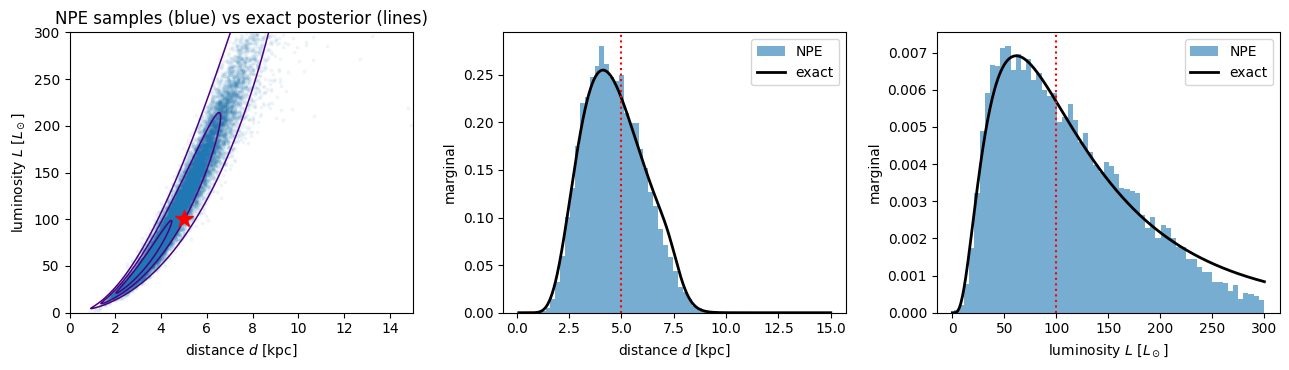

In [5]:
def npe_samples(F_o, n=20000):
    xo = summary(torch.tensor([float(F_o)])).reshape(1, 1).float()
    s = posterior.sample((n,), x=xo, show_progress_bars=False).numpy()
    return s[(s[:,0]>0.1)&(s[:,0]<15)&(s[:,1]>0.1)&(s[:,1]<300)]

s = npe_samples(F_obs)
d, L, Dg, Lg, P, md_d, md_L = exact_posterior(F_obs)
lv = P.max()*np.array([np.exp(-4.5), np.exp(-2.0), np.exp(-0.5)])

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
ax[0].scatter(s[:,0], s[:,1], s=3, alpha=0.05, color='tab:blue', rasterized=True)
ax[0].contour(Dg, Lg, P, levels=lv, colors='indigo', linewidths=1.1)
ax[0].plot(d_true, L_true, 'r*', ms=13)
ax[0].set_xlim(0,15); ax[0].set_ylim(0,300)
ax[0].set_xlabel('distance $d$ [kpc]'); ax[0].set_ylabel('luminosity $L$ [$L_\\odot$]')
ax[0].set_title('NPE samples (blue) vs exact posterior (lines)')
ax[1].hist(s[:,0], bins=60, density=True, alpha=0.6, color='tab:blue', label='NPE')
ax[1].plot(d, md_d, 'k-', lw=2, label='exact'); ax[1].axvline(d_true, color='r', ls=':')
ax[1].set_xlabel('distance $d$ [kpc]'); ax[1].set_ylabel('marginal'); ax[1].legend()
ax[2].hist(s[:,1], bins=60, density=True, alpha=0.6, color='tab:blue', label='NPE')
ax[2].plot(L, md_L, 'k-', lw=2, label='exact'); ax[2].axvline(L_true, color='r', ls=':')
ax[2].set_xlabel('luminosity $L$ [$L_\\odot$]'); ax[2].set_ylabel('marginal'); ax[2].legend()
plt.tight_layout(); plt.show()

## 4. Strength 2 — amortization

The headline feature of NPE: the **same** trained network produces a posterior for *any* observed
flux at negligible cost. Below we feed three different observations (from three different true
$(d,L)$) and compare each NPE posterior to its own exact posterior — with **no re-training**.

A single flux cannot break the $L\propto d^2$ degeneracy (Chapter 1), so each posterior is a long,
thin **banana** along that ridge, with most of its mass at the low-$(d,L)$ end. To compare the two
posteriors *fairly* we draw **matched credible regions** — the smallest regions containing 68% and
95% of the probability — for the exact posterior (solid) and the NPE posterior (dashed). If NPE has
learned the posterior, the two sets of contours coincide in every panel.

(d,L)=(8,80):  d: NPE  9.5+/- 2.9  exact  9.6+/- 2.9   |  L: NPE  81.5+/-51.3  exact  83.8+/-55.4
(d,L)=(5,100):  d: NPE  4.9+/- 1.5  exact  4.9+/- 1.6   |  L: NPE 111.3+/-62.5  exact 115.5+/-67.8


(d,L)=(3,110):  d: NPE  2.8+/- 0.8  exact  2.9+/- 0.9   |  L: NPE 115.1+/-65.5  exact 120.0+/-69.0


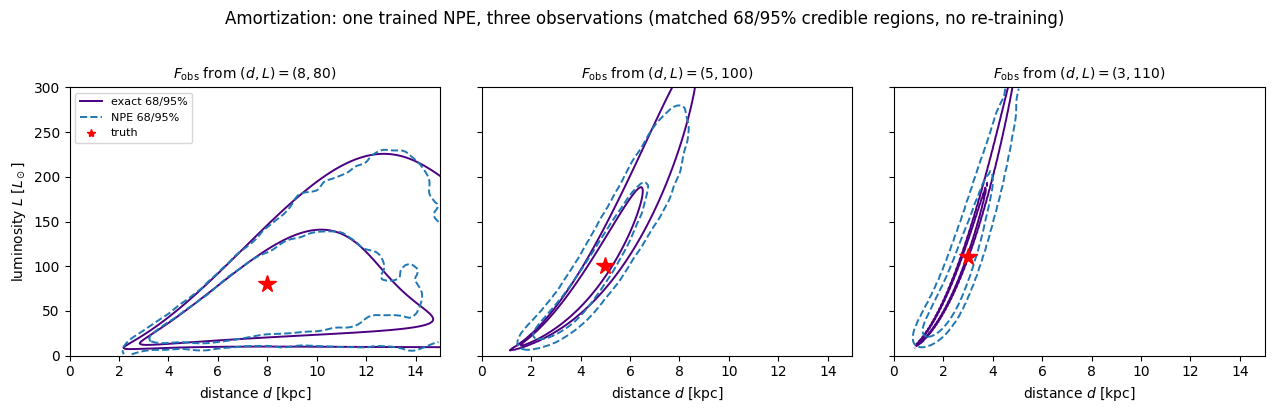

In [6]:
from scipy.ndimage import gaussian_filter
from matplotlib.lines import Line2D

def credible_levels(P, dA, masses=(0.95, 0.68)):
    """Density thresholds enclosing the given probability masses (highest-density regions)."""
    flat = np.sort(P.ravel())[::-1]
    csum = np.cumsum(flat) * dA
    return [flat[min(int(np.searchsorted(csum, m)), len(flat) - 1)] for m in masses]

def npe_grid_density(s, ng=100):
    """Smoothed 2D density of NPE samples on the (d,L) box (same orientation as exact_posterior)."""
    de = np.linspace(0.1, 15, ng + 1); Le = np.linspace(0.1, 300, ng + 1)
    H, _, _ = np.histogram2d(s[:, 0], s[:, 1], bins=[de, Le], density=True)
    H = gaussian_filter(H.T, sigma=2.0)                      # -> (L, d), matching meshgrid(d, L)
    dc = 0.5 * (de[:-1] + de[1:]); Lc = 0.5 * (Le[:-1] + Le[1:])
    Dn, Ln = np.meshgrid(dc, Lc)
    return Dn, Ln, H, (dc[1] - dc[0]) * (Lc[1] - Lc[0])

truths = [(8.0, 80.0), (5.0, 100.0), (3.0, 110.0)]          # faint / medium / bright: ~10x flux range
fig, axes = plt.subplots(1, 3, figsize=(13, 4.0), sharex=True, sharey=True)
for ax, (dt, Lt) in zip(axes, truths):
    Fo = Lt / (FOURPI * dt**2) + sigma_F * np.random.randn()
    s = npe_samples(Fo, n=40000)
    d, L, Dg, Lg, P, md_d, md_L = exact_posterior(Fo, ng=200)
    dA = (d[1] - d[0]) * (L[1] - L[0])
    Dn, Ln, Hn, dAn = npe_grid_density(s)

    ax.contour(Dg, Lg, P, levels=credible_levels(P, dA), colors='indigo', linewidths=1.4)
    ax.contour(Dn, Ln, Hn, levels=credible_levels(Hn, dAn), colors='tab:blue', linewidths=1.4, linestyles='--')
    ax.plot(dt, Lt, 'r*', ms=13, zorder=6)
    ax.set_xlim(0, 15); ax.set_ylim(0, 300)
    ax.set_xlabel('distance $d$ [kpc]')
    ax.set_title(f'$F_{{\\rm obs}}$ from $(d,L)=({dt:.0f},{Lt:.0f})$', fontsize=10)

    # quantitative agreement (exact moments from the grid marginals)
    em_d = (md_d * d).sum() * (d[1] - d[0]); es_d = np.sqrt((md_d * (d - em_d)**2).sum() * (d[1] - d[0]))
    em_L = (md_L * L).sum() * (L[1] - L[0]); es_L = np.sqrt((md_L * (L - em_L)**2).sum() * (L[1] - L[0]))
    print(f"(d,L)=({dt:.0f},{Lt:.0f}):  d: NPE {s[:,0].mean():4.1f}+/-{s[:,0].std():4.1f}  exact {em_d:4.1f}+/-{es_d:4.1f}"
          f"   |  L: NPE {s[:,1].mean():5.1f}+/-{s[:,1].std():4.1f}  exact {em_L:5.1f}+/-{es_L:4.1f}")

axes[0].set_ylabel('luminosity $L$ [$L_\\odot$]')
axes[0].legend(handles=[Line2D([0], [0], color='indigo', lw=1.4, label='exact 68/95%'),
                        Line2D([0], [0], color='tab:blue', lw=1.4, ls='--', label='NPE 68/95%'),
                        Line2D([0], [0], marker='*', color='r', lw=0, label='truth')],
               fontsize=8, loc='upper left')
fig.suptitle('Amortization: one trained NPE, three observations (matched 68/95% credible regions, no re-training)', y=1.02)
plt.tight_layout()
plt.savefig('../fig/sbi_npe_amortized.pdf', bbox_inches='tight')
plt.savefig('../fig/sbi_npe_amortized.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Weakness 1 — calibration depends on the simulation budget

NPE is only as good as its training. We train a second network on a **small** budget and test
both with **simulation-based calibration** (SBC): for a well-calibrated posterior the rank of the
true parameter among posterior samples is **uniform**. A $\cup$-shaped histogram signals
**overconfidence** (posteriors too narrow). The under-trained NPE fails; the well-trained one
passes.

 Training neural network. Epochs trained: 29

 Training neural network. Epochs trained: 58

 Training neural network. Epochs trained: 87

 Training neural network. Epochs trained: 116

 Neural network successfully converged after 135 epochs.

Drawing 200 samples for 300 observations:   0%|          | 0/200 [00:00<?, ?it/s]

Calculating ranks for 300 SBC samples:   0%|          | 0/300 [00:00<?, ?it/s]

Drawing 200 samples for 300 observations:   0%|          | 0/200 [00:00<?, ?it/s]

Calculating ranks for 300 SBC samples:   0%|          | 0/300 [00:00<?, ?it/s]

KS p-values (uniform if >~0.05):  well-trained [0.562 0.843],  small-budget [0.173 0.98 ]


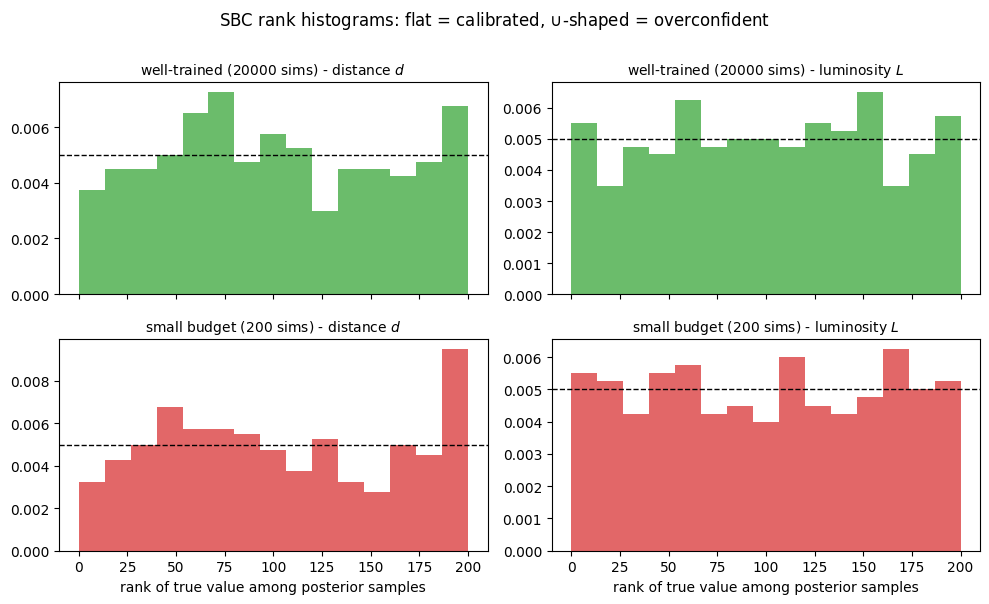

In [7]:
N_small = 200
theta_s = prior.sample((N_small,)).float()
inf_small = NPE(prior=prior)
inf_small.append_simulations(theta_s, simulate(theta_s)).train(show_train_summary=False)
post_small = inf_small.build_posterior()

# simulation-based calibration for both models
n_sbc, n_ps = 300, 200
th_sbc = prior.sample((n_sbc,)).float(); x_sbc = simulate(th_sbc)
ranks_good,  dap_good  = run_sbc(th_sbc, x_sbc, posterior,  num_posterior_samples=n_ps, show_progress_bars=False)
ranks_small, dap_small = run_sbc(th_sbc, x_sbc, post_small, num_posterior_samples=n_ps, show_progress_bars=False)
ks_good  = check_sbc(ranks_good,  th_sbc, dap_good,  num_posterior_samples=n_ps)['ks_pvals'].tolist()
ks_small = check_sbc(ranks_small, th_sbc, dap_small, num_posterior_samples=n_ps)['ks_pvals'].tolist()
print(f"KS p-values (uniform if >~0.05):  well-trained {np.round(ks_good,3)},  small-budget {np.round(ks_small,3)}")

labels = ['distance $d$', 'luminosity $L$']
fig, axes = plt.subplots(2, 2, figsize=(10, 6), sharex=True)
for j in range(2):
    for i, (ranks, name, col) in enumerate([
            (ranks_good,  f'well-trained ({N_good} sims)', 'tab:green'),
            (ranks_small, f'small budget ({N_small} sims)', 'tab:red')]):
        ax = axes[i, j]
        ax.hist(ranks[:, j].numpy(), bins=15, range=(0, n_ps), density=True, color=col, alpha=0.7)
        ax.axhline(1.0/n_ps, color='k', ls='--', lw=1)   # uniform reference
        ax.set_title(f'{name} - {labels[j]}', fontsize=10)
        if i == 1:
            ax.set_xlabel('rank of true value among posterior samples')
fig.suptitle('SBC rank histograms: flat = calibrated, $\\cup$-shaped = overconfident', y=1.0)
plt.tight_layout()
plt.savefig('../fig/sbi_npe_sbc.pdf', bbox_inches='tight')
plt.savefig('../fig/sbi_npe_sbc.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Weakness 2 — out-of-distribution observations

NPE only learned the posterior on data resembling its simulations. If we feed an observation
**outside the prior-predictive support**, the flow extrapolates and returns a posterior that is
**confidently wrong**. We mark an anomalously bright flux against the distribution of simulated
fluxes, then compare the NPE posterior there to the in-distribution case.

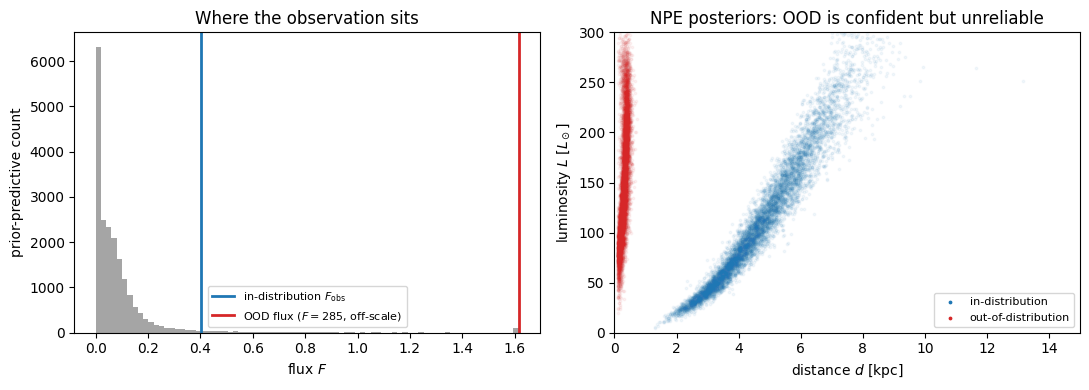

In [8]:
# prior-predictive distribution of the flux, and two observations to compare
tt = prior.sample((20000,)).float()
F_pred = (tt[:, 1]/(FOURPI*tt[:, 0]**2) + sigma_F*torch.randn(tt.shape[0])).numpy()
F_ood = F_pred.max()*5.0          # far brighter than anything the network was trained on

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
hi = np.percentile(F_pred, 99.5)
ax[0].hist(np.clip(F_pred, 0, hi), bins=80, color='tab:gray', alpha=0.7)
ax[0].axvline(F_obs, color='tab:blue', lw=2, label='in-distribution $F_{\\rm obs}$')
ax[0].axvline(hi, color='tab:red', lw=2, label=f'OOD flux ($F={F_ood:.0f}$, off-scale)')
ax[0].set_xlabel('flux $F$'); ax[0].set_ylabel('prior-predictive count')
ax[0].legend(fontsize=8); ax[0].set_title('Where the observation sits')

s_in  = npe_samples(F_obs, n=8000)
s_ood = npe_samples(F_ood, n=8000)
ax[1].scatter(s_in[:, 0],  s_in[:, 1],  s=3, alpha=0.05, color='tab:blue', label='in-distribution', rasterized=True)
ax[1].scatter(s_ood[:, 0], s_ood[:, 1], s=3, alpha=0.05, color='tab:red',  label='out-of-distribution', rasterized=True)
ax[1].set_xlim(0, 15); ax[1].set_ylim(0, 300)
ax[1].set_xlabel('distance $d$ [kpc]'); ax[1].set_ylabel('luminosity $L$ [$L_\\odot$]')
ax[1].set_title('NPE posteriors: OOD is confident but unreliable')
lg = ax[1].legend(fontsize=8)
for h in lg.legend_handles: h.set_alpha(1)
plt.tight_layout()
plt.savefig('../fig/sbi_npe_ood.pdf', bbox_inches='tight')
plt.savefig('../fig/sbi_npe_ood.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Takeaways

* **NPE is accurate and simulation-efficient** here: it matches the exact posterior from
  $2\times10^4$ simulations, far fewer than ABC needs.
* **Amortization** is the decisive practical advantage — train once, infer for arbitrarily many
  observations instantly (ideal for surveys with millions of objects, cf. Section 10.5).
* But the posterior is **trustworthy only after validation**: with too small a simulation budget
  it is overconfident and fails SBC, and for **out-of-distribution** observations it is confidently
  wrong. This is exactly why the diagnostics of Section 10.7 (SBC, coverage, posterior predictive
  checks) are mandatory before believing an SBI posterior.

## Appendix: summary figure for the lecture notes

A single two-panel figure that distils the NPE story for Chapter 10: **(left)** the strength —
amortization: one trained network gives correct posteriors for several different observations
(NPE vs exact 95% credible regions); **(right)** a key weakness — calibration depends on the
simulation budget: the under-trained NPE produces a $\cup$-shaped SBC rank histogram
(overconfident), while the well-trained one is flat. Saved to `../fig/sbi_npe_summary.pdf`.

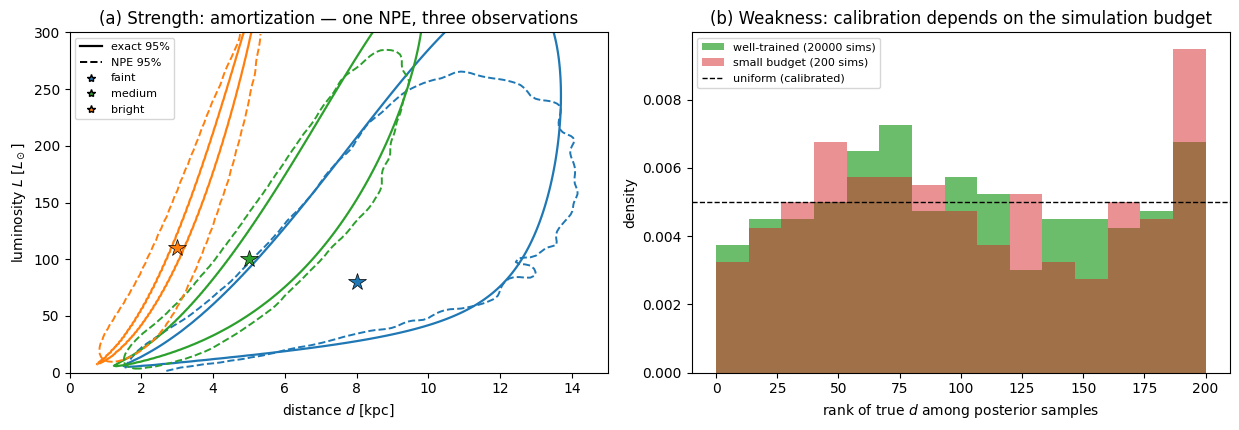

In [9]:
from matplotlib.lines import Line2D

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.5, 4.4))

# (left) amortization: one network, three observations, 95% credible regions (exact vs NPE)
np.random.seed(7)
cols = ['tab:blue', 'tab:green', 'tab:orange']
labs = ['faint', 'medium', 'bright']
for (dt, Lt), col, lab in zip([(8.0, 80.0), (5.0, 100.0), (3.0, 110.0)], cols, labs):
    Fo = Lt/(FOURPI*dt**2) + sigma_F*np.random.randn()
    s = npe_samples(Fo, n=40000)
    d, L, Dg, Lg, P, _, _ = exact_posterior(Fo, ng=200)
    dA = (d[1]-d[0])*(L[1]-L[0])
    Dn, Ln, Hn, dAn = npe_grid_density(s)
    axL.contour(Dg, Lg, P,  levels=credible_levels(P,  dA,  masses=(0.95,)), colors=col, linewidths=1.6)
    axL.contour(Dn, Ln, Hn, levels=credible_levels(Hn, dAn, masses=(0.95,)), colors=col, linewidths=1.4, linestyles='--')
    axL.plot(dt, Lt, '*', color=col, ms=13, mec='k', mew=0.5, zorder=6)
axL.set_xlim(0, 15); axL.set_ylim(0, 300)
axL.set_xlabel('distance $d$ [kpc]'); axL.set_ylabel('luminosity $L$ [$L_\\odot$]')
axL.set_title('(a) Strength: amortization — one NPE, three observations')
axL.legend(handles=[Line2D([0],[0],color='k',lw=1.6,label='exact 95%'),
                    Line2D([0],[0],color='k',lw=1.4,ls='--',label='NPE 95%')] +
                   [Line2D([0],[0],marker='*',color=c,lw=0,mec='k',label=l) for c,l in zip(cols,labs)],
           fontsize=8, loc='upper left')

# (right) weakness: SBC calibration of the distance rank depends on the simulation budget
axR.hist(ranks_good[:, 0].numpy(),  bins=15, range=(0, n_ps), density=True, color='tab:green',
         alpha=0.7, label=f'well-trained ({N_good} sims)')
axR.hist(ranks_small[:, 0].numpy(), bins=15, range=(0, n_ps), density=True, color='tab:red',
         alpha=0.5, label=f'small budget ({N_small} sims)')
axR.axhline(1.0/n_ps, color='k', ls='--', lw=1, label='uniform (calibrated)')
axR.set_xlabel('rank of true $d$ among posterior samples'); axR.set_ylabel('density')
axR.set_title('(b) Weakness: calibration depends on the simulation budget')
axR.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../fig/sbi_npe_summary.pdf', bbox_inches='tight')
plt.savefig('../fig/sbi_npe_summary.png', dpi=150, bbox_inches='tight')
plt.show()